<a href="https://colab.research.google.com/github/KarlyHdzC/Mineria_de_datos/blob/main/Copia_de_Miner%C3%ADa_de_Datos_Sesion_1_chunk_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad Anáhuac Puebla
## Minería de datos
## Profesor: Farid Krayem Pineda Ph.D.

**Ejemplos de escalado**

# Ejemplo de escalado

In [1]:
import numpy as np
import pandas as pd

# Dataset crudo (intencionalmente con escalas dispares)
df = pd.DataFrame({
    "Ingresos": [9500, 12000, 35000, 40000, 10500, 38000, 15000, 42000, 1000],
    "Edad":     [22, 25, 41, 39, 24, 40, 29, 38, 16],
    "Altura":   [1.62, 1.70, 1.68, 1.75, 1.60, 1.72, 1.69, 1.78, 1.70]
}, index=[f"P{i}" for i in range(1, 10)])

df

,Ingresos,Edad,Altura
P1,9500,22,1.62
P2,12000,25,1.70
P3,35000,41,1.68
P4,40000,39,1.75
P5,10500,24,1.60
P6,38000,40,1.72
P7,15000,29,1.69
P8,42000,38,1.78
P9,1000,16,1.70


In [2]:
from scipy.spatial.distance import pdist, squareform
import pandas as pd

dist_matrix = squareform(pdist(df.values, metric='euclidean'))
dist_df = pd.DataFrame(dist_matrix, index=df.index, columns=df.index)

dist_df

,P1,P2,P3,P4,P5,P6,P7,P8,P9
P1,0.000000,2500.001801,25500.007079,30500.004738,1000.002000,28500.005684,5500.004455,32500.003939,8500.002118
P2,2500.001801,0.000000,23000.005565,28000.003500,1500.000337,26000.004327,3000.002667,30000.002817,11000.003682
P3,25500.007079,23000.005565,0.000000,5000.000400,24500.005898,3000.000167,20000.003600,7000.000644,34000.009191
P4,30500.004738,28000.003500,5000.000400,0.000000,29500.003814,2000.000250,25000.002000,2000.000250,39000.006782
P5,1000.002000,1500.000337,24500.005898,29500.003814,0.000000,27500.004655,4500.002779,31500.003112,9500.003369
P6,28500.005684,26000.004327,3000.000167,2000.000250,27500.004655,0.000000,23000.002630,4000.000500,37000.007784
P7,5500.004455,3000.002667,20000.003600,25000.002000,4500.002779,23000.002630,0.000000,27000.001500,14000.006036
P8,32500.003939,30000.002817,7000.000644,2000.000250,31500.003112,4000.000500,27000.001500,0.000000,41000.005903
P9,8500.002118,11000.003682,34000.009191,39000.006782,9500.003369,37000.007784,14000.006036,41000.005903,0.000000


/tmp/ipykernel_12871/869449281.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot([x[i], x[j]], [y[i], y[j]], alpha=0.2)
/tmp/ipykernel_12871/869449281.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(x[i], y[i], label)


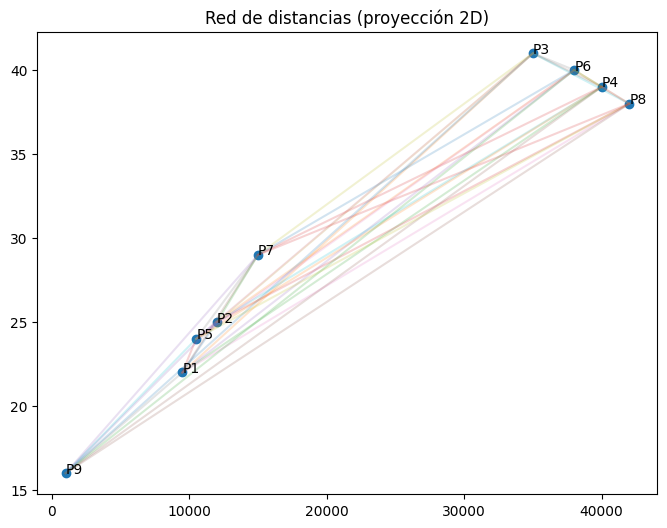

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# posiciones simples (solo para visualizar)
x = df["Ingresos"]
y = df["Edad"]

plt.scatter(x, y)

# conectar todos contra todos (puedes filtrar si quieres)
for i in range(len(df)):
    for j in range(i+1, len(df)):
        plt.plot([x[i], x[j]], [y[i], y[j]], alpha=0.2)

# etiquetas
for i, label in enumerate(df.index):
    plt.text(x[i], y[i], label)

plt.title("Red de distancias (proyección 2D)")
plt.show()

In [5]:
# Distancia Euclidiana (sin preprocesamiento)
X = df.values
labels = df.index.tolist()

#Distancia de la línea recta
def dist(a, b):
    return np.sqrt(((a - b) ** 2).sum())

# Elegimos una persona "query" y buscamos sus 3 más cercanas
query = "P1"
qi = labels.index(query)

dists = []
for j, name in enumerate(labels):
    if j == qi:
        continue
    dists.append((name, dist(X[qi], X[j])))

sorted(dists, key=lambda x: x[1])[:3]

[('P5', np.float64(1000.0020001979996)),
 ('P2', np.float64(2500.001801279351)),
 ('P7', np.float64(5500.0044549891045))]

In [6]:
print(labels)

['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9']


In [7]:
print(X)

[[9.50e+03 2.20e+01 1.62e+00]
 [1.20e+04 2.50e+01 1.70e+00]
 [3.50e+04 4.10e+01 1.68e+00]
 [4.00e+04 3.90e+01 1.75e+00]
 [1.05e+04 2.40e+01 1.60e+00]
 [3.80e+04 4.00e+01 1.72e+00]
 [1.50e+04 2.90e+01 1.69e+00]
 [4.20e+04 3.80e+01 1.78e+00]
 [1.00e+03 1.60e+01 1.70e+00]]


In [9]:
# Distancias de menor a mayor
# para que exista la distancia tiene que existir un punto de comparación
sorted(dists, key=lambda x: x[1])

[('P5', np.float64(1000.0020001979996)),
 ('P2', np.float64(2500.001801279351)),
 ('P7', np.float64(5500.0044549891045)),
 ('P9', np.float64(8500.002118023265)),
 ('P3', np.float64(25500.007078500978)),
 ('P6', np.float64(28500.005684385396)),
 ('P4', np.float64(30500.0047379816)),
 ('P8', np.float64(32500.003938855145))]

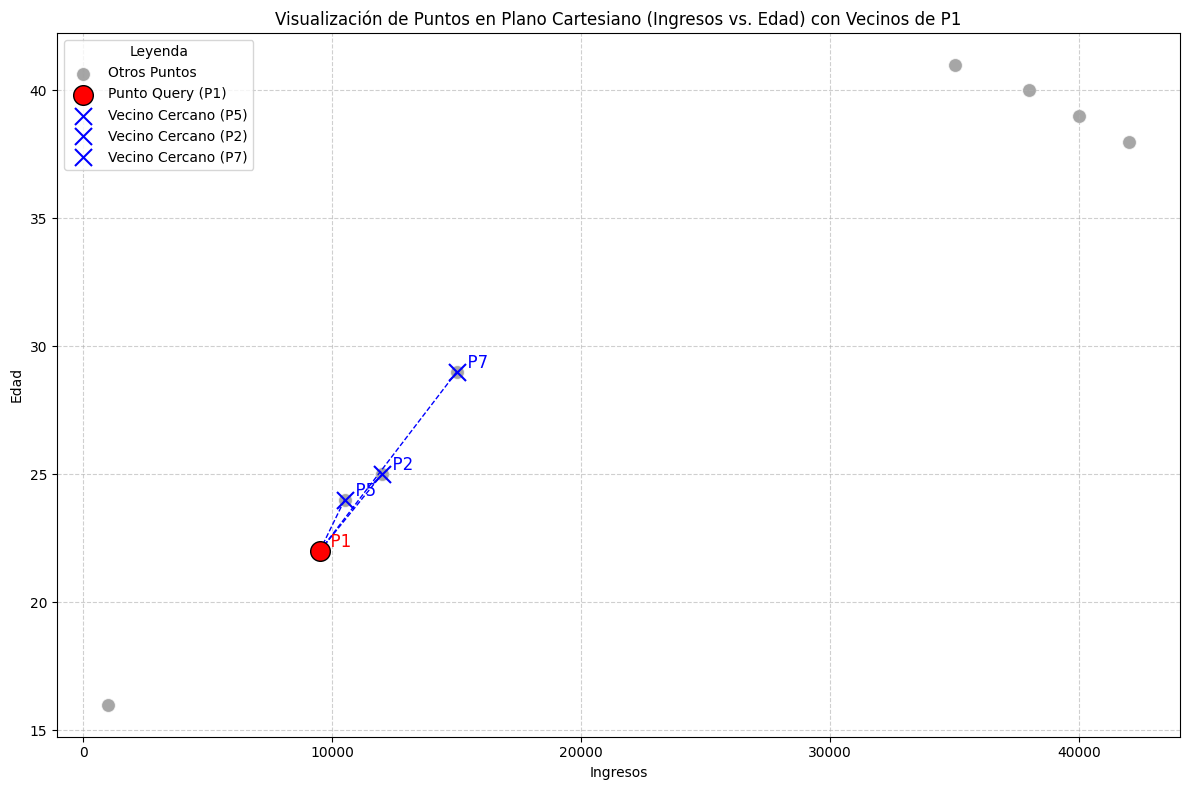

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(x='Ingresos', y='Edad', data=df, s=100, color='gray', alpha=0.7, label='Otros Puntos')

# Highlight the query point P1
plt.scatter(df.loc[query, 'Ingresos'], df.loc[query, 'Edad'], color='red', s=200, marker='o', edgecolor='black', zorder=5, label=f'Punto Query ({query})')
plt.text(df.loc[query, 'Ingresos'], df.loc[query, 'Edad'], f'  {query}', fontsize=12, ha='left', va='bottom', color='red')

# Get the top 3 closest points (from the unscaled calculation)
closest_3_unscaled = sorted(dists, key=lambda x: x[1])[:3]
closest_names = [name for name, _ in closest_3_unscaled]

# Highlight the closest points
for name in closest_names:
    plt.scatter(df.loc[name, 'Ingresos'], df.loc[name, 'Edad'], color='blue', s=150, marker='x', zorder=4, label=f'Vecino Cercano ({name})') # Removed edgecolor
    plt.text(df.loc[name, 'Ingresos'], df.loc[name, 'Edad'], f'  {name}', fontsize=12, ha='left', va='bottom', color='blue')
    # Draw a line from query point to neighbor
    plt.plot([df.loc[query, 'Ingresos'], df.loc[name, 'Ingresos']],
             [df.loc[query, 'Edad'], df.loc[name, 'Edad']],
             color='blue', linestyle='--', linewidth=1)

plt.title(f'Visualización de Puntos en Plano Cartesiano (Ingresos vs. Edad) con Vecinos de {query}')
plt.xlabel('Ingresos')
plt.ylabel('Edad')
plt.grid(True, linestyle='--', alpha=0.6)
# Create custom legend handles to avoid duplicate labels from loop
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Leyenda')
plt.tight_layout()
plt.show()

En este gráfico de dispersión, podemos ver la distribución de los puntos en el plano cartesiano definido por 'Ingresos' y 'Edad'. El punto P1 (en rojo) es nuestra referencia, y los puntos en azul con una 'x' son sus tres vecinos más cercanos según la distancia euclidiana *sin escalar* (P5, P2, P7). Las líneas punteadas ilustran la "distancia" entre P1 y estos vecinos en esta proyección 2D.

Es evidente cómo la gran dispersión en la variable `Ingresos` (eje horizontal) hace que las diferencias en esta dimensión dominen visualmente cualquier proximidad basada en la `Edad` (eje vertical). Este gráfico refuerza la observación de que, sin un escalado previo, las variables con rangos de valores más grandes tienen un peso desproporcionado en el cálculo de la distancia euclidiana.

Cambien query = "P1" por "P3" o "P6" y vuelvan a correr.

* “¿Qué tanto cambia la distancia si dos personas difieren en ingresos vs. en edad?”

* “Si edad varía ~20-60, ¿cuánto pesa eso frente a ingresos que varían 9,500–42,000?”

* “¿Qué variable está determinando realmente quién es ‘cercano’?”

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

labels = df.index.tolist()

X = df.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Repetimos el mismo cálculo de vecinos cercanos, pero ahora con X_scaled
def knn_like(query_name, k=3):
    qi = labels.index(query_name)
    dists = []
    for j, name in enumerate(labels):
        if j == qi:
            continue
        d = np.sqrt(((X_scaled[qi] - X_scaled[j])**2).sum())
        dists.append((name, d))
    return sorted(dists, key=lambda x: x[1])[:k]

knn_like("P1", k=3)

[('P5', np.float64(0.44321673908884657)),
 ('P2', np.float64(1.542198850018055)),
 ('P7', np.float64(1.5768367634594216))]

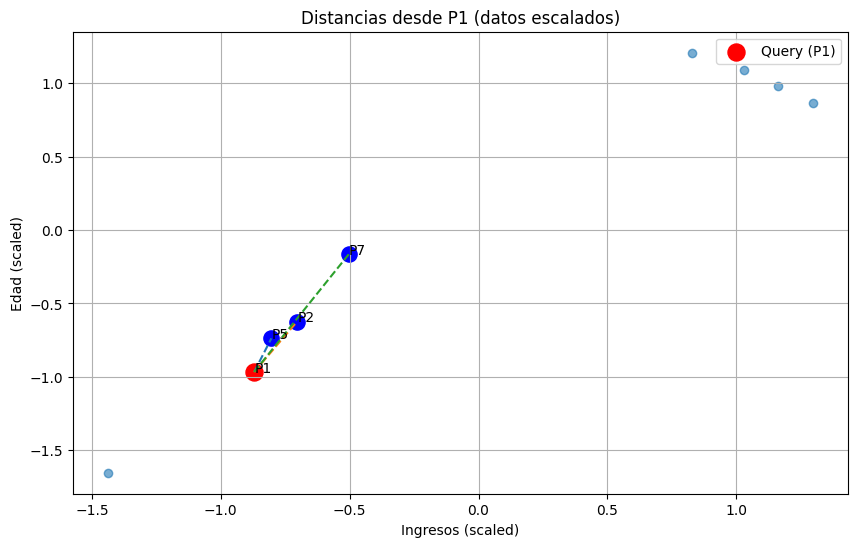

In [12]:
import matplotlib.pyplot as plt

query = "P1"
qi = labels.index(query)

plt.figure(figsize=(10, 6))

# Usamos datos escalados
x = X_scaled[:, 0]  # Ingresos (scaled)
y = X_scaled[:, 1]  # Edad (scaled)

# Todos los puntos
plt.scatter(x, y, alpha=0.6)

# Punto query
plt.scatter(x[qi], y[qi], color="red", s=150, label="Query (P1)")

# Calcular vecinos con datos escalados
neighbors = knn_like(query, k=3)

for name, dist in neighbors:
    j = labels.index(name)

    # Punto vecino
    plt.scatter(x[j], y[j], color="blue", s=120)

    # Línea de distancia
    plt.plot([x[qi], x[j]],
             [y[qi], y[j]],
             linestyle="--")

    # Etiqueta
    plt.text(x[j], y[j], name)

# Etiqueta del query
plt.text(x[qi], y[qi], query)

plt.xlabel("Ingresos (scaled)")
plt.ylabel("Edad (scaled)")
plt.title("Distancias desde P1 (datos escalados)")
plt.legend()
plt.grid(True)
plt.show()

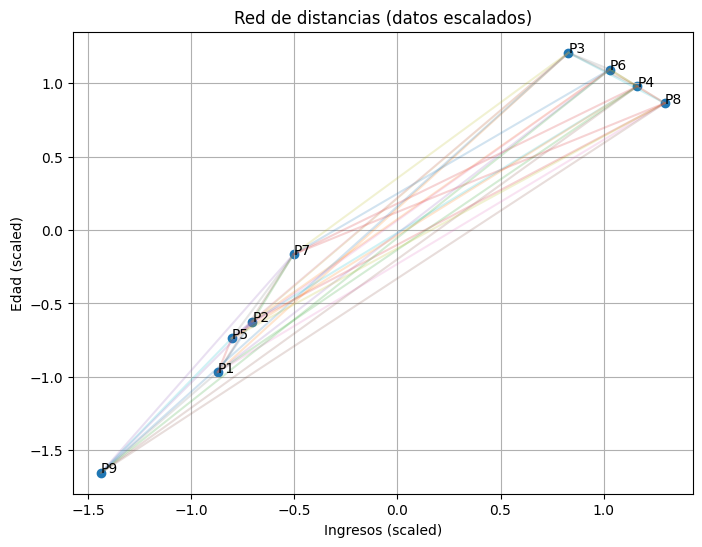

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# usar datos escalados
x = X_scaled[:, 0]  # Ingresos (scaled)
y = X_scaled[:, 1]  # Edad (scaled)

# scatter
plt.scatter(x, y)

# conectar todos contra todos
for i in range(len(X_scaled)):
    for j in range(i+1, len(X_scaled)):
        plt.plot([x[i], x[j]], [y[i], y[j]], alpha=0.2)

# etiquetas
for i, label in enumerate(labels):
    plt.text(x[i], y[i], label)

plt.title("Red de distancias (datos escalados)")
plt.xlabel("Ingresos (scaled)")
plt.ylabel("Edad (scaled)")
plt.grid(True)

plt.show()

## ¿Cambió el ranking de cercanos? ¿Por qué eso es bueno?

Dejen como texto/markdown en Colab:

**“Pipeline de preprocesamiento para minería (distancias)”**

* Verificar escalas y unidades

> StandardScaler antes de cualquier método de distancia

* Mantener el escalado dentro de un Pipeline reproducible

* Documentar qué variables y por qué



## ¿Qué hace exactamente `StandardScaler`?

`StandardScaler` **transforma cada variable para que:**

* tenga **media = 0**
* tenga **desviación estándar = 1**

Es decir, convierte todas las variables a la **misma escala estadística**.

Formalmente, para cada valor ($x$):

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

donde:

* $\mu$ = media de la variable
* $\sigma$ = desviación estándar
---

## Traducción conceptual (sin matemáticas)

`StandardScaler` responde a esta pregunta:

> *“¿Qué tan lejos está este valor del promedio de su variable, en unidades de desviación estándar?”*

Ya no importa si era:

* pesos
* años
* metros
  todo pasa a ser **“cuántos sigmas me alejo del promedio”**.

---

## Ejemplo claro

Supongamos dos personas:

| Variable | P1    | P3     |
| -------- | ----- | ------ |
| Ingresos | 9,500 | 35,000 |
| Edad     | 22    | 41     |
| Altura   | 1.62  | 1.68   |

### Sin escalar:

* Diferencia en ingresos: **25,500**
* Diferencia en edad: **19**
* Diferencia en altura: **0.06**

La distancia está dominada por **25,500** → ingresos manda.

---

### Con `StandardScaler`:

Ahora cada valor se convierte en algo así (conceptualmente):

| Variable | P1 (scaled) | P3 (scaled) |
| -------- | ----------- | ----------- |
| Ingresos | -1.12       | +0.95       |
| Edad     | -1.05       | +0.88       |
| Altura   | -0.60       | +0.10       |

Las diferencias son del mismo orden de magnitud.
Ahora **cada variable pesa parecido** en la geometría.

---

## Qué NO hace (error común)

`StandardScaler` **NO:**

* normaliza a [0,1]
* elimina outliers
* hace los datos “bonitos”
* mejora mágicamente el modelo

Solo hace una cosa:

> **cambia la geometría del espacio.**

---

## La definición profunda

`StandardScaler` convierte el espacio original en un espacio donde:

* cada eje tiene varianza 1
* el origen es el centro de masa del dataset
* la distancia euclidiana se vuelve una medida de **desviación relativa**, no absoluta

Es decir:

> Pasas de medir *“distancia en unidades físicas”*
> a medir *“distancia en rareza estadística”*.

---

> **StandardScaler no cambia los datos, cambia el significado de la distancia.**


